# Synthetic SIR Data Generation

This notebook generates synthetic data using SIR model.
True parameters:
- beta = 0.3
- gamma = 0.1

## 1. Import libraries and set path

We import required libraries and add the project root to Python path
so that modules in `src` can be used.

In [1]:
import sys
import os

# src 경로 추가 (중요!)
sys.path.append(os.path.abspath("../"))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.model import solve_sir

## 2. Define true parameters and initial conditions

In [2]:
# True parameters
beta_true = 0.3
gamma_true = 0.1

# Initial condition
S0 = 999
I0 = 1
R0 = 0

# Time grid
t = np.linspace(0, 100, 101)

## 3. Solve SIR model

We simulate the SIR model using the true parameters.

In [3]:
S, I, R = solve_sir(beta_true, gamma_true, S0, I0, R0, t)

## 4. Generate noisy observations

We assume that only the infected population \( I(t) \) is observed,
and measurement noise follows a Gaussian distribution.

In [4]:
np.random.seed(42)

noise_std = 10  # noise level
I_obs = I + np.random.normal(0, noise_std, size=len(I))

## 5. Visualization

We compare the true trajectory and noisy observations.

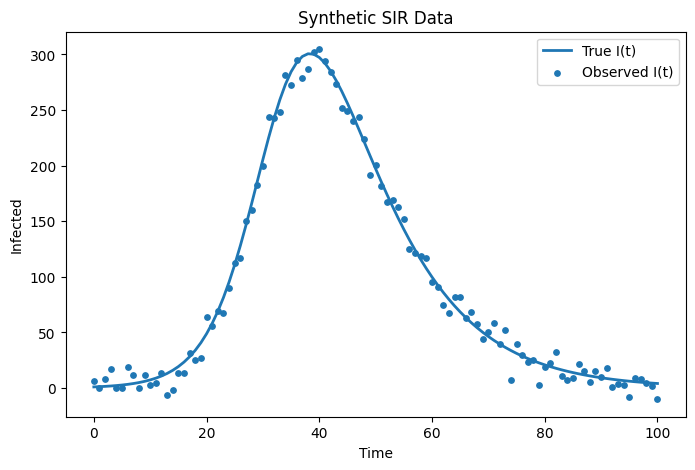

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(t, I, label="True I(t)", linewidth=2)
plt.scatter(t, I_obs, label="Observed I(t)", s=15)

plt.xlabel("Time")
plt.ylabel("Infected")
plt.legend()
plt.title("Synthetic SIR Data")

plt.show()

## 6. Save dataset

The generated data will be saved for later use in parameter estimation.

In [ ]:
df = pd.DataFrame({
    "t": t,
    "I_obs": I_obs
})

os.makedirs("../data", exist_ok=True)
df.to_csv("../data/synthetic_sir.csv", index=False)

print("Data saved to ../data/synthetic_sir.csv")